### Visualize Predictions -- Leah Edits

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

In [ ]:
# =====================================================
# Combined Visualization Script
# - Green-dot deviation plot
# - AUC/ROC curve
# =====================================================


# -----------------------------------------------------
# Load predictions
# -----------------------------------------------------
###Edit this to file path of whatever is the best model 
df = pd.read_csv("/projects/e32998/MIL_training/final_runs/run_20260314_190215/predictions.csv")

# Sort so true=0 cases appear first (optional but cleaner)
df_sorted = df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
df_sorted["case_str"] = df_sorted["case_id"].astype(str)

In [3]:
df.head()

,case_id,true_label,predicted_label,correct,prob_class0,prob_class1
0,14,1,1,True,0.000009,0.999991
1,15,1,1,True,0.397283,0.602717
2,17,1,1,True,0.002104,0.997896
3,19,1,1,True,0.000592,0.999408
4,22,0,0,True,0.995256,0.004744


Confusion matrix can be found in the /projects/e32998/MIL_training/final_runs/'best run id'/ folder.

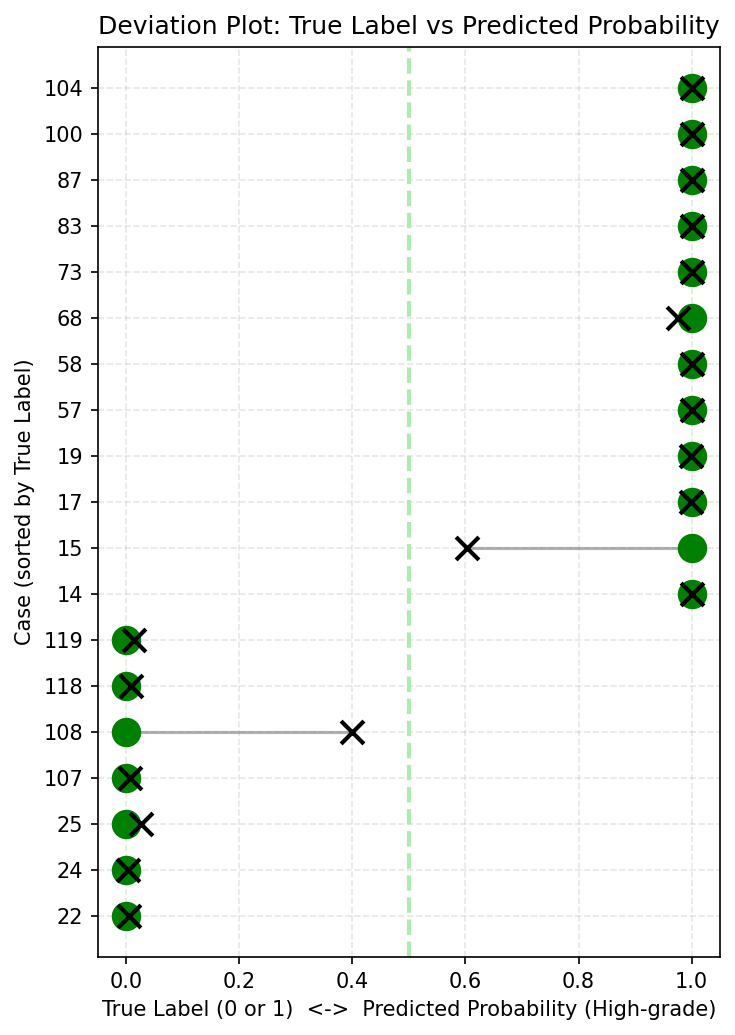

In [4]:
# -----------------------------------------------------
# 1. Deviation Plot (True vs Probabilities)
# -----------------------------------------------------
plt.figure(figsize=(5,7), dpi=150)

for i, row in df_sorted.iterrows():
    # connecting line
    plt.plot(
        [row["true_label"], row["prob_class1"]],
        [i, i],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )

    # true label = large green circle
    plt.scatter(
        row["true_label"], i,
        color="green",
        s=200,
        marker="o",
        edgecolor="black",
        linewidth=0,
        zorder=3
    )

    # predicted probability = small black X
    plt.scatter(
        row["prob_class1"], i,
        color="black",
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(df_sorted)), df_sorted["case_str"])
plt.axvline(0.5, color="#ADEBB3", linestyle="--", linewidth=2, label="Decision Threshold (0.5)")
plt.xlabel("True Label (0 or 1)  <->  Predicted Probability (High-grade)")
plt.ylabel("Case (sorted by True Label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

    Epoch  Train Loss  Val Loss
0       1      1.0389    0.4924
1       2      0.3599    0.4224
2       3      0.3680    0.4681
3       4      0.2629    0.4344
4       5      0.2358    0.6828
5       6      0.3294    0.6200
6       7      0.2502    1.1927
7       8      0.1279    0.8258
8       9      0.0546    0.8139
9      10      0.0097    0.8862
10     11      0.0063    0.9247
11     12      0.0163    0.9615
12     13      0.0051    0.9755
13     14     -0.0042    0.9697
14     15     -0.0106    0.9705
15     16      0.0016    0.9609
16     17     -0.0070    0.9663
17     18      0.0122    0.9715
18     19     -0.0094    0.9752
19     20     -0.0008    0.9687
20     21     -0.0076    0.9687
21     22     -0.0054    0.9686
22     23     -0.0064    0.9670
23     24     -0.0053    0.9667
24     25      0.0064    0.9682
25     26     -0.0049    0.9689
26     27     -0.0059    0.9695
27     28      0.0020    0.9664
28     29     -0.0079    0.9672
29     30     -0.0032    0.9705


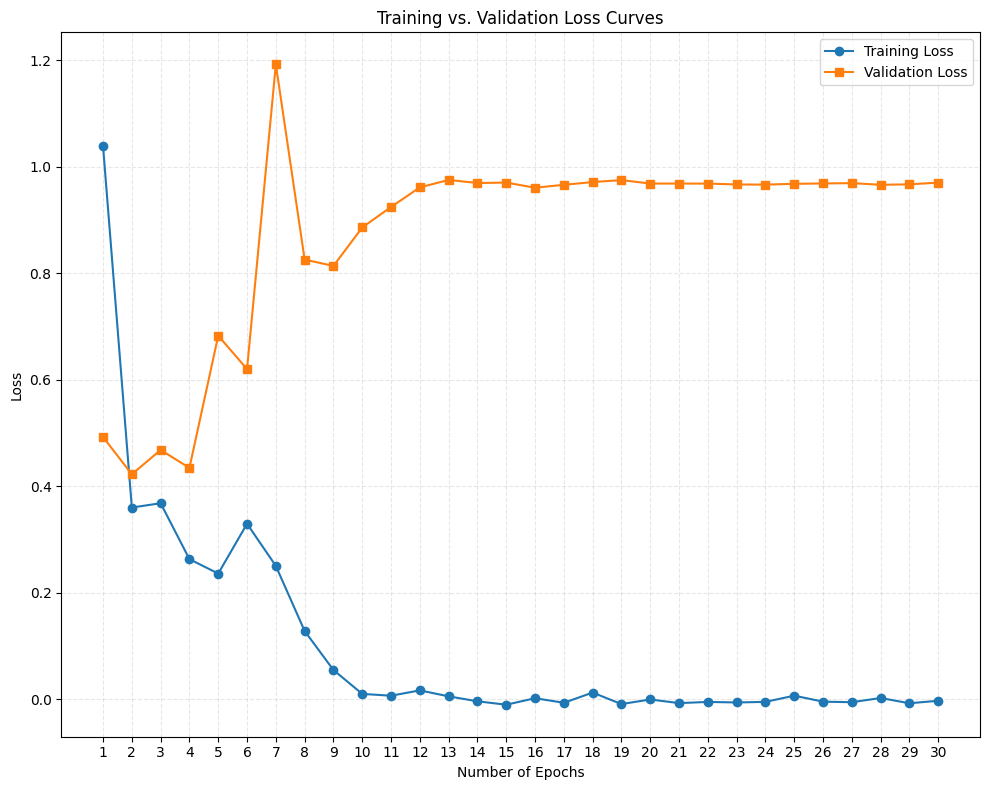

In [7]:
# -----------------------------------------------------
# 2. Training vs. Validation Loss Curves
# -----------------------------------------------------
import re
records = []

with open("/projects/e32998/STAT390_Winter2026/Team3/Code/sofie_presentation3/output/model_best_paramsfeb27_30epochs_xsplit2.out", "r") as f:
    content = f.read()

# Split into epoch blocks
blocks = re.split(r"(?=Epoch \d+/\d+)", content)

for block in blocks:
    epoch_match    = re.search(r"Epoch (\d+)/\d+", block)
    train_match =    re.search(r"Train Loss:\s*(-?[\d.]+)", block)
    val_loss_match = re.search(r"Val Loss:\s*(-?[\d.]+)", block)

    if epoch_match and train_match and val_loss_match:
        records.append({
            "Epoch":      int(epoch_match.group(1)),
            "Train Loss": float(train_match.group(1)),
            "Val Loss":   float(val_loss_match.group(1))
        })

df2 = pd.DataFrame(records)
print(df2)

plt.figure(figsize=(10, 8))

plt.plot(df2["Epoch"], df2["Train Loss"], label="Training Loss", marker="o")
plt.plot(df2["Epoch"], df2["Val Loss"], label="Validation Loss", marker="s")
plt.legend()
plt.xticks(df2["Epoch"])
plt.xlabel("Number of Epochs")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss Curves")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()